In [22]:
#i have imported libraries only once at the beginning,
#hence please run the following cell before running any
#other cell

In [23]:
import numpy as np, matplotlib.pyplot as plt
import sympy as sm

Solution to Question 1

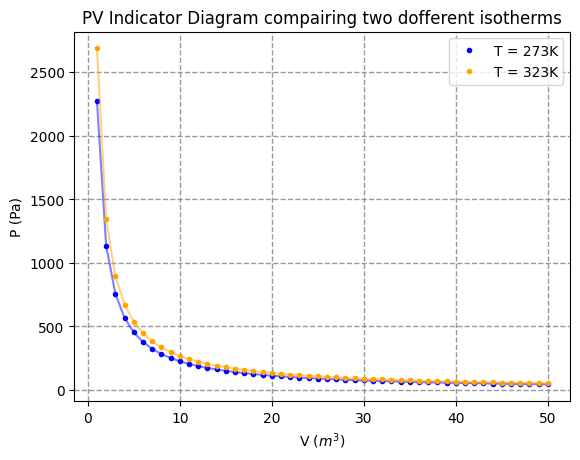

In [24]:
#Part a

def Pressure(V, #m^3
             T, #K
             n = 1 #moles
             ):
    R = 8.314 #J/(mol K)
    P = n*R*T/V #Pa #using the ideal gas state equation
    return(P)

#Part b

Volumes = np.array(range(1,51)) #m^3
T1 = 273 #K
T2 = 323 #K
'''
Now as we have fixed 2 of the 3 coordinates in the Ideal Gas Equation, we can calculate the third and visualize it in the indicator diagram as below
'''
#directly calculating the Pressure values by inputing whole array of volumes and getting areay of pressure values as output while plotting
#since we have discrete vakues of volumes it is better to plot scatter plot and show the expected continuous curve behind it

plt.plot(Volumes, Pressure(Volumes, T1), '.', label = f'T = {T1}K', color = 'blue') #for points
plt.plot(Volumes, Pressure(Volumes, T1), alpha = 0.5, color = 'blue') #for joining the points with some transparency
#similarly plotting commands for temperature T2
plt.plot(Volumes, Pressure(Volumes, T2), '.', label = f'T = {T2}K', color = 'orange')
plt.plot(Volumes, Pressure(Volumes, T2), alpha = 0.5, color = 'orange')
plt.title("PV Indicator Diagram compairing two dofferent isotherms") #setting the title of the graph
plt.xlabel(r"V ($m^3$)") #the label on x axis
plt.ylabel("P (Pa)") #the label on y axis
plt.grid(True, linewidth = 1.0, color = 'grey', alpha = 0.8, linestyle = '--') #setting up the grid
plt.legend() #to display the legend, just writing label command in plt.plot() will not make it visible
plt.show()

Solution to Question 2

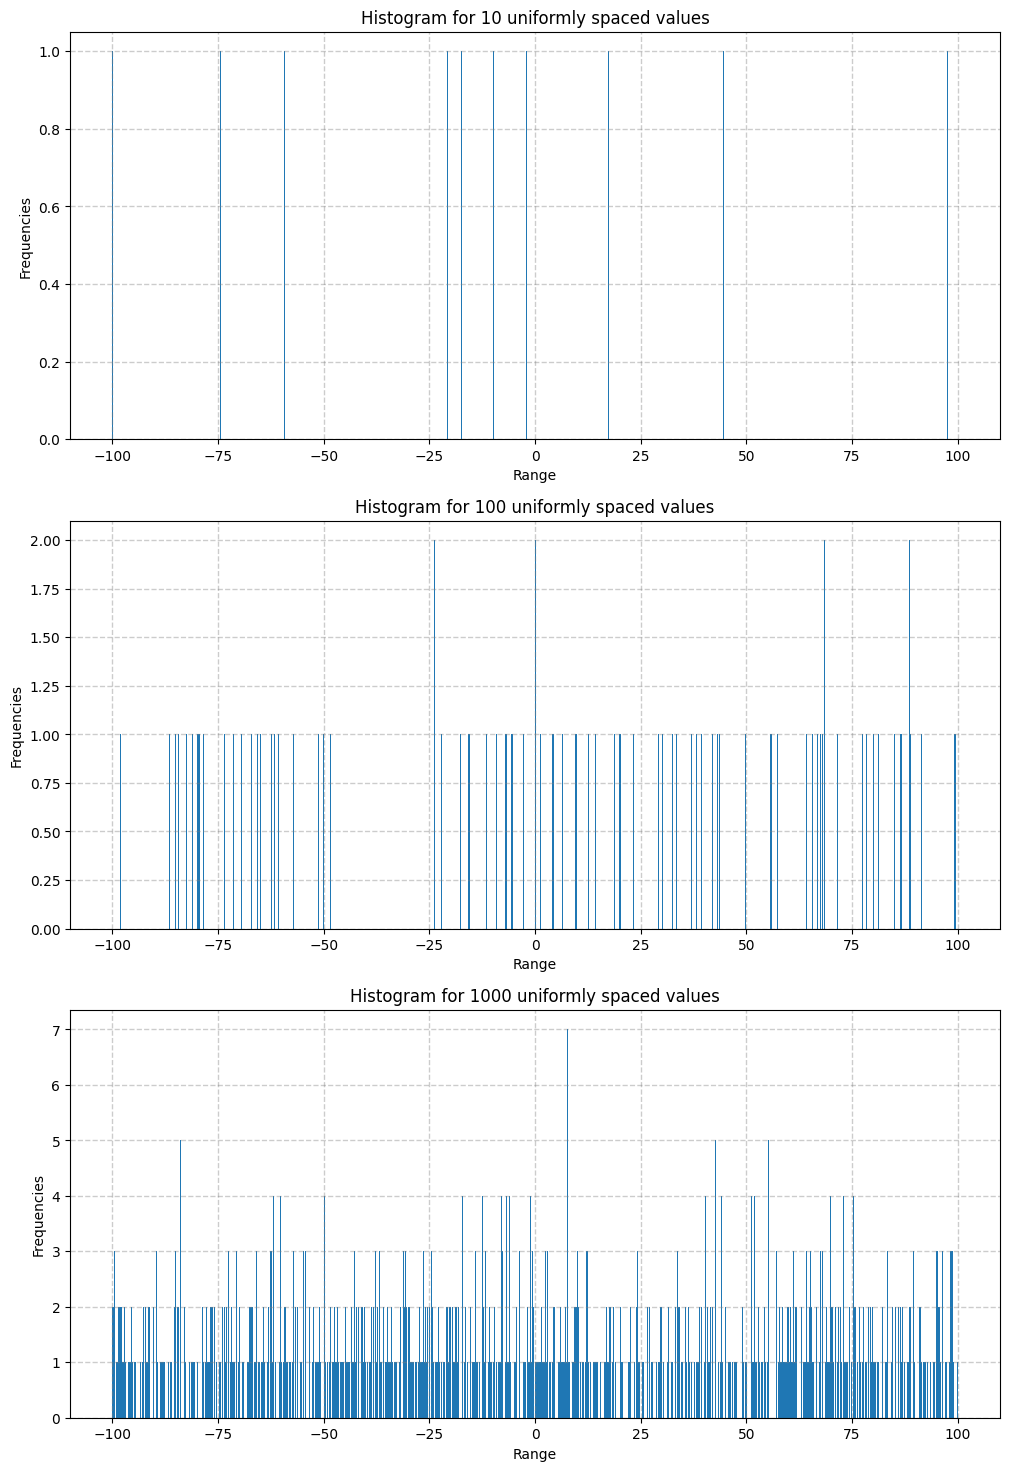

In [25]:
#Part a

arr_1 = np.random.uniform(low = -100, high = 101, size = 10) #generates 10 random uniform values in the range
arr_2 = np.random.uniform(low = -100, high = 101, size = 100) #generates 100 of them
arr_3 = np.random.uniform(low = -100, high = 101, size = 1000) #generates 1000 of them

#Part b

fig, ax = plt.subplots(3,1, figsize = (12, 18))

ax[0].hist(arr_1, bins = 1000, range = (-100, 100))
ax[0].set_title("Histogram for 10 uniformly spaced values")
ax[0].set_xlabel("Range")
ax[0].set_ylabel("Frequencies")
ax[0].grid(True, linewidth = 1.0, color = 'grey', alpha = 0.4, linestyle = '--')

ax[1].hist(arr_2, bins = 1000, range = (-100, 100))
ax[1].set_title("Histogram for 100 uniformly spaced values")
ax[1].set_xlabel("Range")
ax[1].set_ylabel("Frequencies")
ax[1].grid(True, linewidth = 1.0, color = 'grey', alpha = 0.4, linestyle = '--')

ax[2].hist(arr_3, bins = 1000, range = (-100, 100))
ax[2].set_title("Histogram for 1000 uniformly spaced values")
ax[2].set_xlabel("Range")
ax[2].set_ylabel("Frequencies")
ax[2].grid(True, linewidth = 1.0, color = 'grey', alpha = 0.4, linestyle = '--')

plt.show()

part c

Since the program is generating random values on every run we get different histograms for every run. In the first histogram, where we can easily count 10 bins, we see that in some runs the number of bars shown in the diagram are less than 10 (or to be more precise, we see that the sum of frequencies is less than 10). This is actually because the range on x axis is contracted into a small width to fit it on our screen which makes it difficult to distinguish the bars which are too close.

As we increase the number of data points in our range for the histogram, we find that the distribution starts to converge to being almost perfectly flat, we see fluctuations which can be seen to cancel out resulting in a flatter distribution compared to the lesser data points case.

It must be theoretically flat when random data points are choosen uniformly since then each bin will have same probability of getting a data point, and hence then same number of data points would fall in each bin when creating array of data points (exceptions discussed below which discusses how many number of data points we choose affects the flattness);

When we use random values, more than one value can be selected from a bin and maybe 0 from another. Also for small datasets, the values selected may be either locally concentrated or widely spread acoss the histogram. But for large datasets it is highly unlikely for the values to be concentrated.



- Exceptions for getting flat distribution:

  Let number of values choosen be a, and number of bins be b

1. HCF(a,b) $\neq$ min(a,b); (example a=6 and b=9; HCF=3)
2. LCM(a,b) $\neq$ max(a,b); (example a=21 and b=14; LCM=42)

- When these exceptions are left out, we can have 2 ideal cases:

1. when a \< b (example a=3, b=9) we get a sort of flat distribution, but it is more of a square wave distribution since if we assume equally spaced data points then only every $n^{th}$ bin will contain the data point for n satisfies b=na, $\forall$ n $\in$ I
2. when a $\geq$ b (example a=21, b=7) then assuming that each bin gets equal data points, it'll also be a flat distribution which is the most perfect for those a data points. The data points going into each bin equals n for n satisfies a=nb, $\forall$ n $\in$ I

Solution to Question 3

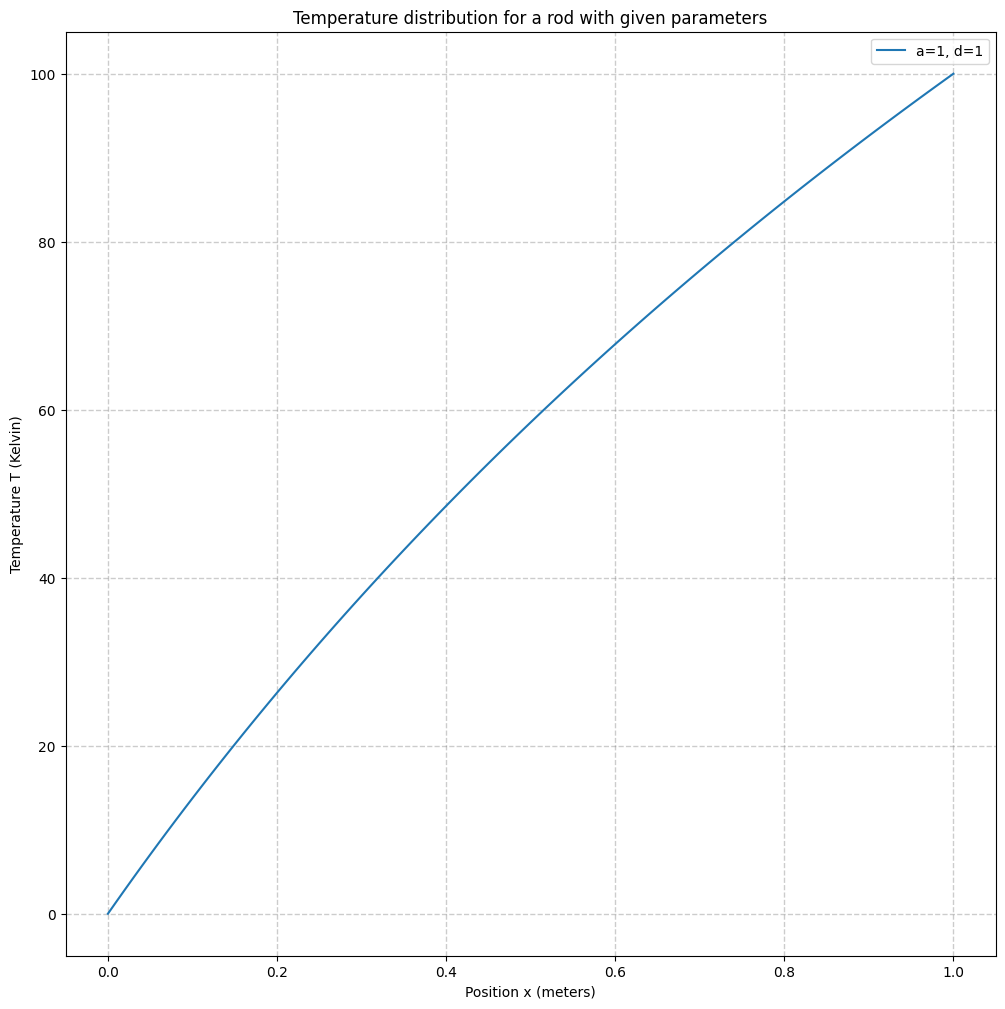

In [26]:
# Part a

class ThermalRod:
  #Using the __init__ method to store values of parameters a and d for a particular rod
  def __init__(self, a, d):
    self.a=a  #stores value of a in self.a
    self.d=d  #stores the value of d in self.d
  def get_temperature(self, x, #m
                      T_hot, #K
                      T_cold=0, #K
                      Length=1, #m
                      Area=1 #m^2
                      ):  #used default arguments for assuming some parameters of the rod

    #k(x)=ax+d
    #k=self.a*x+self.d  #to obtain value of k
    x1=sm.symbols('x1') #creating a symbol x1 which represents the location where we want to find temperature
    func=1/((self.a*x1+self.d)*Area)  #here k isn't used so as to use the variable x1 for integration by sympy
    T=T_cold + (T_hot-T_cold)*sm.integrate(func, (x1, 0, x))/sm.integrate(func, (x1, 0, Length))
    return(T)

# Part b

x=np.arange(0, 1.01, 0.01)  #since arange function excludes the upper limit, hence added 0.01 (step size) in the upper limit
Length=1 #m
a=1
d=1
Hot_end=100 #temperature of hot end assumed in kelvins
rod=ThermalRod(a=a, d=d)
Temp=[rod.get_temperature(x=x_val, T_hot=Hot_end, Length=Length) for x_val in x] #this method of list comprehension creates a list of temperature values obtained

plt.figure(figsize=(12, 12))

plt.plot(x, Temp, label=f'a={a}, d={d}')
plt.title('Temperature distribution for a rod with given parameters')
plt.xlabel('Position x (meters)')
plt.ylabel('Temperature T (Kelvin)')
plt.legend()
plt.grid(True, linewidth=1.0, alpha =0.4, color='grey', linestyle='--')
plt.show()

Solution to Question 4

In [27]:
# Part a

specific_heat_capacities={'Water':4180, 'Iron':483, 'Copper':399, 'Aluminum':882}
# the above dictionary contains material names as keys in form of strings and their resctive specific heat capacities as values in units J/(kg K)


# Part b

def mixing(Mass_hot, #Mass of hot water in kg
           Temp, #initial temperature of hot water (degree Celsius)
           Mass_ice #mass of ice at 0 degree Celsius
           ):
  C_water=4180 #specific heat capacity of water given in J/(kg K)
  L_fusion=334 #latent heat of fusion given for ice in J/kg

  Q_water=Mass_hot*C_water*Temp #heat initially in hot water
  Q_melt=Mass_ice*L_fusion #heat required to melt all of the ice

  if Q_water < Q_melt: #water is not hot enough to melt all the ice
    msg=f'All of the ice could not be melted and {Q_water/L_fusion} kg ice remains'
  else:
    heat_remain=Q_water-Q_melt #heat remaining in the system (system is mixture of water and ice)
    temp_after_melting=heat_remain/((Mass_hot+Mass_ice)*C_water) #equilibrium temperature of system after mixing
    msg=f'All of the ice melted with final equilibrium temperature of mixture = {temp_after_melting} Celsius'

  return(msg)